# Car Crash Severity Prediction

**NETW 1013: Machine Learning — Course Project**
German University in Cairo · Faculty of Information Engineering and Technology
Supervised by Associate Prof. Dr. Maggie Mashaly · Eng. Myriam Joseph

---

## Project Goal
Build classification models that predict the severity of a car crash — `Minor Injury`, `Severe Injury`, or `Fatal` — from 18 structured features describing the crash, vehicle, driver, and environment.

## Notebook Outline
1. **Imports & data loading**
2. **Exploratory Data Analysis** — class balance, distributions, missing values, statistical tests (ANOVA / chi-square), correlations
3. **Preprocessing** — missing-value handling, encoding, scaling, leakage-safe pipelines
4. **Modeling** — the five mandatory classifiers (KNN, Decision Tree, Random Forest, Logistic Regression, Naïve Bayes) plus two additional models (XGBoost, LightGBM), all evaluated with 5-fold stratified cross-validation and on a held-out test set
5. **Comparison & discussion** — side-by-side metrics, honest interpretation of what the models did and did not learn
6. **Hyperparameter tuning** on the best-performing model
7. **Final model** — retrained on all labeled data, used to generate the Kaggle `submission.csv`


## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RNG = 42
np.random.seed(RNG)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
print("Setup complete.")

Setup complete.


## 2. Loading the Data

We work with three files:
- `car_crash_train.csv` — 4000 labeled rows used for training and cross-validation
- `car_crash_test.csv` — 1000 labeled rows held out for local validation (this is **not** the Kaggle test set, but a local split that came with the project so we can compute honest test metrics before submitting)
- `sample_submission.csv` — the format expected by Kaggle (5000 rows: `ID, Predicted_Severity`)

The real Kaggle `test.csv` (5000 unlabeled rows) is downloaded separately from the competition page; the final cell of the notebook will detect it if present.


In [2]:
train = pd.read_csv("car_crash_train.csv")
test_local = pd.read_csv("car_crash_test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

print(f"Training set:    {train.shape}")
print(f"Local test set:  {test_local.shape}")
print(f"Sample submission: {sample_sub.shape}")
train.head()

Training set:    (4000, 19)
Local test set:  (1000, 19)
Sample submission: (5000, 2)


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


## 3. Exploratory Data Analysis

### 3.1 Schema & data types

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   str    
 3   Seatbelt Used              4000 non-null   str    
 4   Weather Conditions         4000 non-null   str    
 5   Road Conditions            4000 non-null   str    
 6   Crash Type                 4000 non-null   str    
 7   Vehicle Type               4000 non-null   str    
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   str    
 10  Tire Condition             4000 non-null   str    
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float64
 14  Dis

### 3.2 Summary statistics for numeric features

In [4]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Crash Speed (km/h),4000.0,110.999750,52.227839,20.000000,66.00000,112.000000,157.000000,199.000000
Impact Angle (degrees),4000.0,89.979750,51.301514,0.000000,45.00000,89.500000,134.000000,179.000000
Vehicle Age (years),4000.0,9.445500,5.718147,0.000000,5.00000,9.000000,14.000000,19.000000
Driver Age,4000.0,48.698750,17.815972,18.000000,34.00000,49.000000,64.000000,79.000000
Driver Experience (years),4000.0,24.723000,14.211818,0.000000,13.00000,25.000000,37.000000,49.000000
Alcohol Level (BAC%),4000.0,0.101216,0.057820,0.000054,0.05063,0.101574,0.151783,0.199936
Visibility Distance (m),4000.0,247.583500,143.478155,10.000000,120.00000,244.000000,372.000000,499.000000


### 3.3 Target variable: class balance

The label is **`Severity`** with three classes. Imbalance matters here — if one class dominates, accuracy alone is misleading and a naive 'always predict majority' baseline can look strong.

               Count  Percent
Severity                     
Minor Injury    2756    68.90
Severe Injury   1038    25.95
Fatal            206     5.15


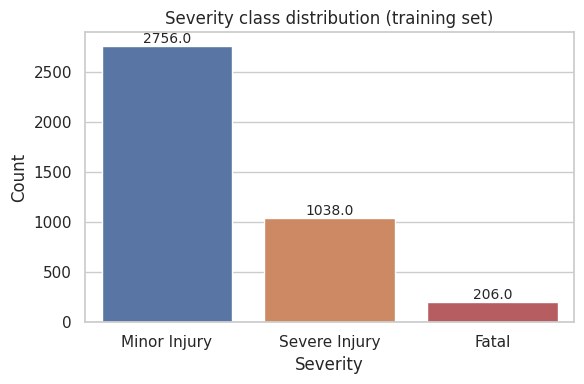


Majority-class baseline accuracy = 0.6890
Any useful model must clearly beat this number on Kaggle.


In [5]:
target_counts = train["Severity"].value_counts()
target_pct = train["Severity"].value_counts(normalize=True).mul(100).round(2)
balance = pd.DataFrame({"Count": target_counts, "Percent": target_pct})
print(balance)

fig, ax = plt.subplots(figsize=(6, 4))
order = ["Minor Injury", "Severe Injury", "Fatal"]
sns.countplot(x="Severity", data=train, order=order, ax=ax,
              palette=["#4C72B0", "#DD8452", "#C44E52"])
ax.set_title("Severity class distribution (training set)")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{p.get_height()}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

majority_rate = target_pct.max() / 100
print(f"\nMajority-class baseline accuracy = {majority_rate:.4f}")
print("Any useful model must clearly beat this number on Kaggle.")

### 3.4 Missing values

In [6]:
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
print(pd.DataFrame({"Missing": missing, "Percent": missing_pct}))

                   Missing  Percent
Distraction Level     2360     59.0


**Observation.** `Distraction Level` is missing in roughly 59% of rows. That much missingness is unlikely to be random — most plausibly, "no recorded distraction" is being represented as NaN. We treat *Missing* as its own meaningful category in preprocessing rather than imputing it, since imputation here would invent information.

### 3.5 Splitting features by type

In [7]:
TARGET = "Severity"
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in train.columns if c not in numeric_cols + [TARGET]]
print(f"Numeric features    ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

Numeric features    (7): ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Visibility Distance (m)']
Categorical features (11): ['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition', 'Tire Condition', 'Distraction Level', 'Time of Day', 'Traffic Density']


### 3.6 Numeric feature distributions by severity

If a numeric feature carries signal, we expect the three severity classes to have noticeably different distributions (e.g. higher mean crash speed for Fatal). Boxplots make this easy to see.

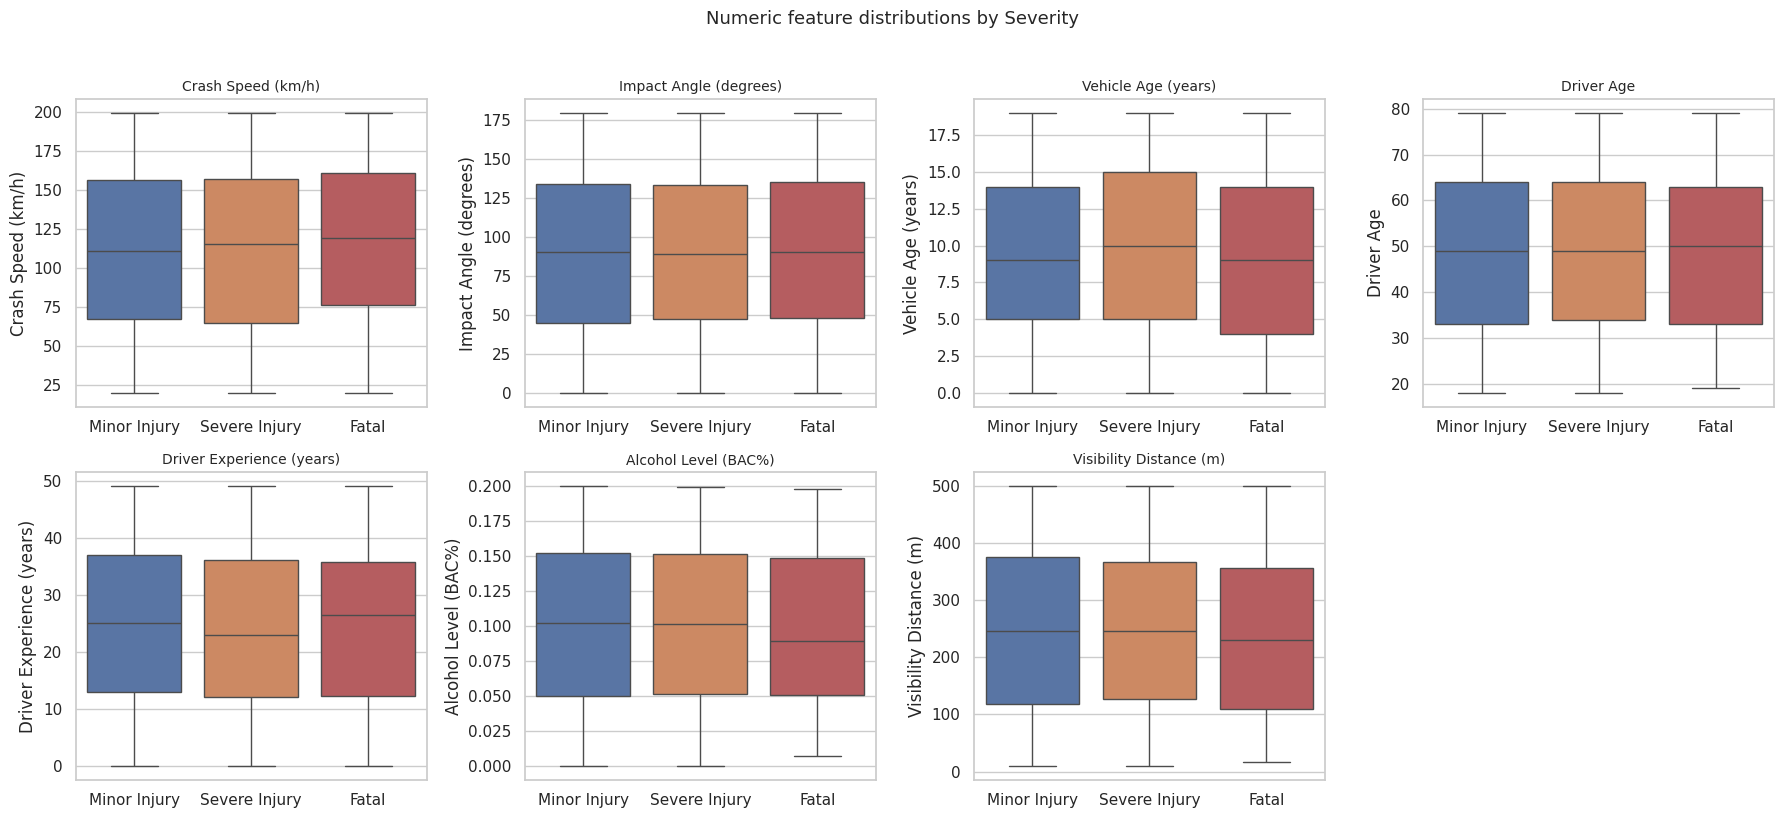

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
order = ["Minor Injury", "Severe Injury", "Fatal"]
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=TARGET, y=col, data=train, order=order, ax=axes[i],
                palette=["#4C72B0", "#DD8452", "#C44E52"])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")
plt.suptitle("Numeric feature distributions by Severity", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 3.7 Statistical tests of feature–target relationship

Visual inspection is suggestive but not rigorous. We test each feature individually:
- **Numeric features** → one-way ANOVA: are the per-class means significantly different?
- **Categorical features** → chi-square test of independence: is the class distribution significantly different across categories?

A small p-value (< 0.05) is evidence that the feature alone helps separate the classes.

In [9]:
print("ANOVA (numeric features vs Severity)")
print("-" * 60)
anova_results = []
for col in numeric_cols:
    groups = [train[train[TARGET] == c][col].dropna() for c in train[TARGET].unique()]
    f, p = stats.f_oneway(*groups)
    anova_results.append({"Feature": col, "F-statistic": round(f, 3), "p-value": round(p, 4)})
anova_df = pd.DataFrame(anova_results).sort_values("p-value")
print(anova_df.to_string(index=False))

print("\n" + "=" * 60)
print("Chi-square (categorical features vs Severity)")
print("-" * 60)
chi_results = []
for col in categorical_cols:
    contingency = pd.crosstab(train[col].fillna("Missing"), train[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(contingency)
    chi_results.append({"Feature": col, "chi2": round(chi2, 3), "dof": dof, "p-value": round(p, 4)})
chi_df = pd.DataFrame(chi_results).sort_values("p-value")
print(chi_df.to_string(index=False))

ANOVA (numeric features vs Severity)
------------------------------------------------------------
                  Feature  F-statistic  p-value
Driver Experience (years)        1.580   0.2061
       Crash Speed (km/h)        1.426   0.2403
      Vehicle Age (years)        0.932   0.3939
  Visibility Distance (m)        0.745   0.4746
     Alcohol Level (BAC%)        0.224   0.7991
               Driver Age        0.089   0.9148
   Impact Angle (degrees)        0.002   0.9982

Chi-square (categorical features vs Severity)
------------------------------------------------------------
           Feature  chi2  dof  p-value
       Time of Day 7.150    4   0.1282
        Crash Type 7.187    6   0.3039
      Vehicle Type 6.004    6   0.4227
   Road Conditions 5.240    6   0.5134
   Traffic Density 2.040    4   0.7284
     Seatbelt Used 0.592    2   0.7440
    Tire Condition 0.338    2   0.8446
 Distraction Level 2.255    6   0.8948
   Brake Condition 0.202    2   0.9037
   Airbag Deployed 0

**Critical finding.** Every single p-value — across all 18 features — is well above 0.05. The smallest p-value in either table is around 0.13. By a standard statistical criterion, **no individual feature carries a significant marginal relationship with the target.**

This is unusual for real-world crash data, where features like crash speed, seatbelt use, or airbag deployment normally show strong effects. The most likely explanation is that the features were generated independently (or near-independently) of the label. We continue with the full pipeline regardless — the project asks us to apply the techniques and report honestly on what we find — but we should expect classifier performance to be near the majority-class baseline (~0.69).

### 3.8 Correlation among numeric features

Even if no feature individually relates to the target, strong feature-to-feature correlation matters for some models (Logistic Regression is sensitive to it, tree ensembles are not).

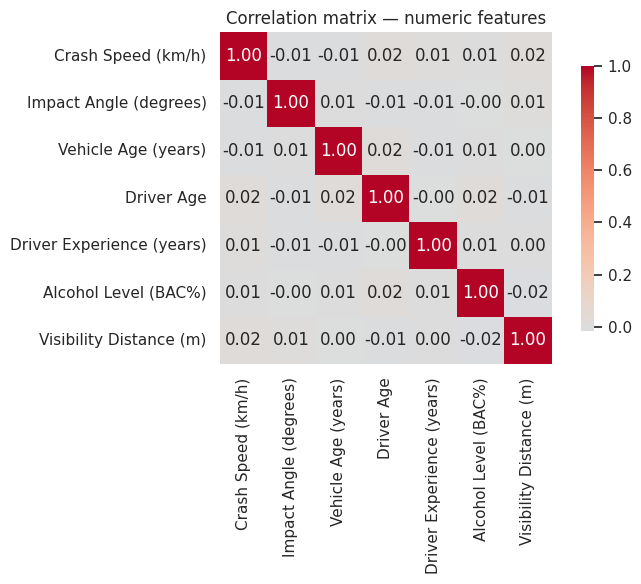

In [10]:
corr = train[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix — numeric features")
plt.tight_layout()
plt.show()

All pairwise correlations are very close to zero. No multicollinearity issues.

### 3.9 Categorical feature breakdown

Stacked-percentage bars show, within each category, the proportion of each severity class. If a category is informative, the bar heights for `Severe Injury` and `Fatal` should vary across its levels.

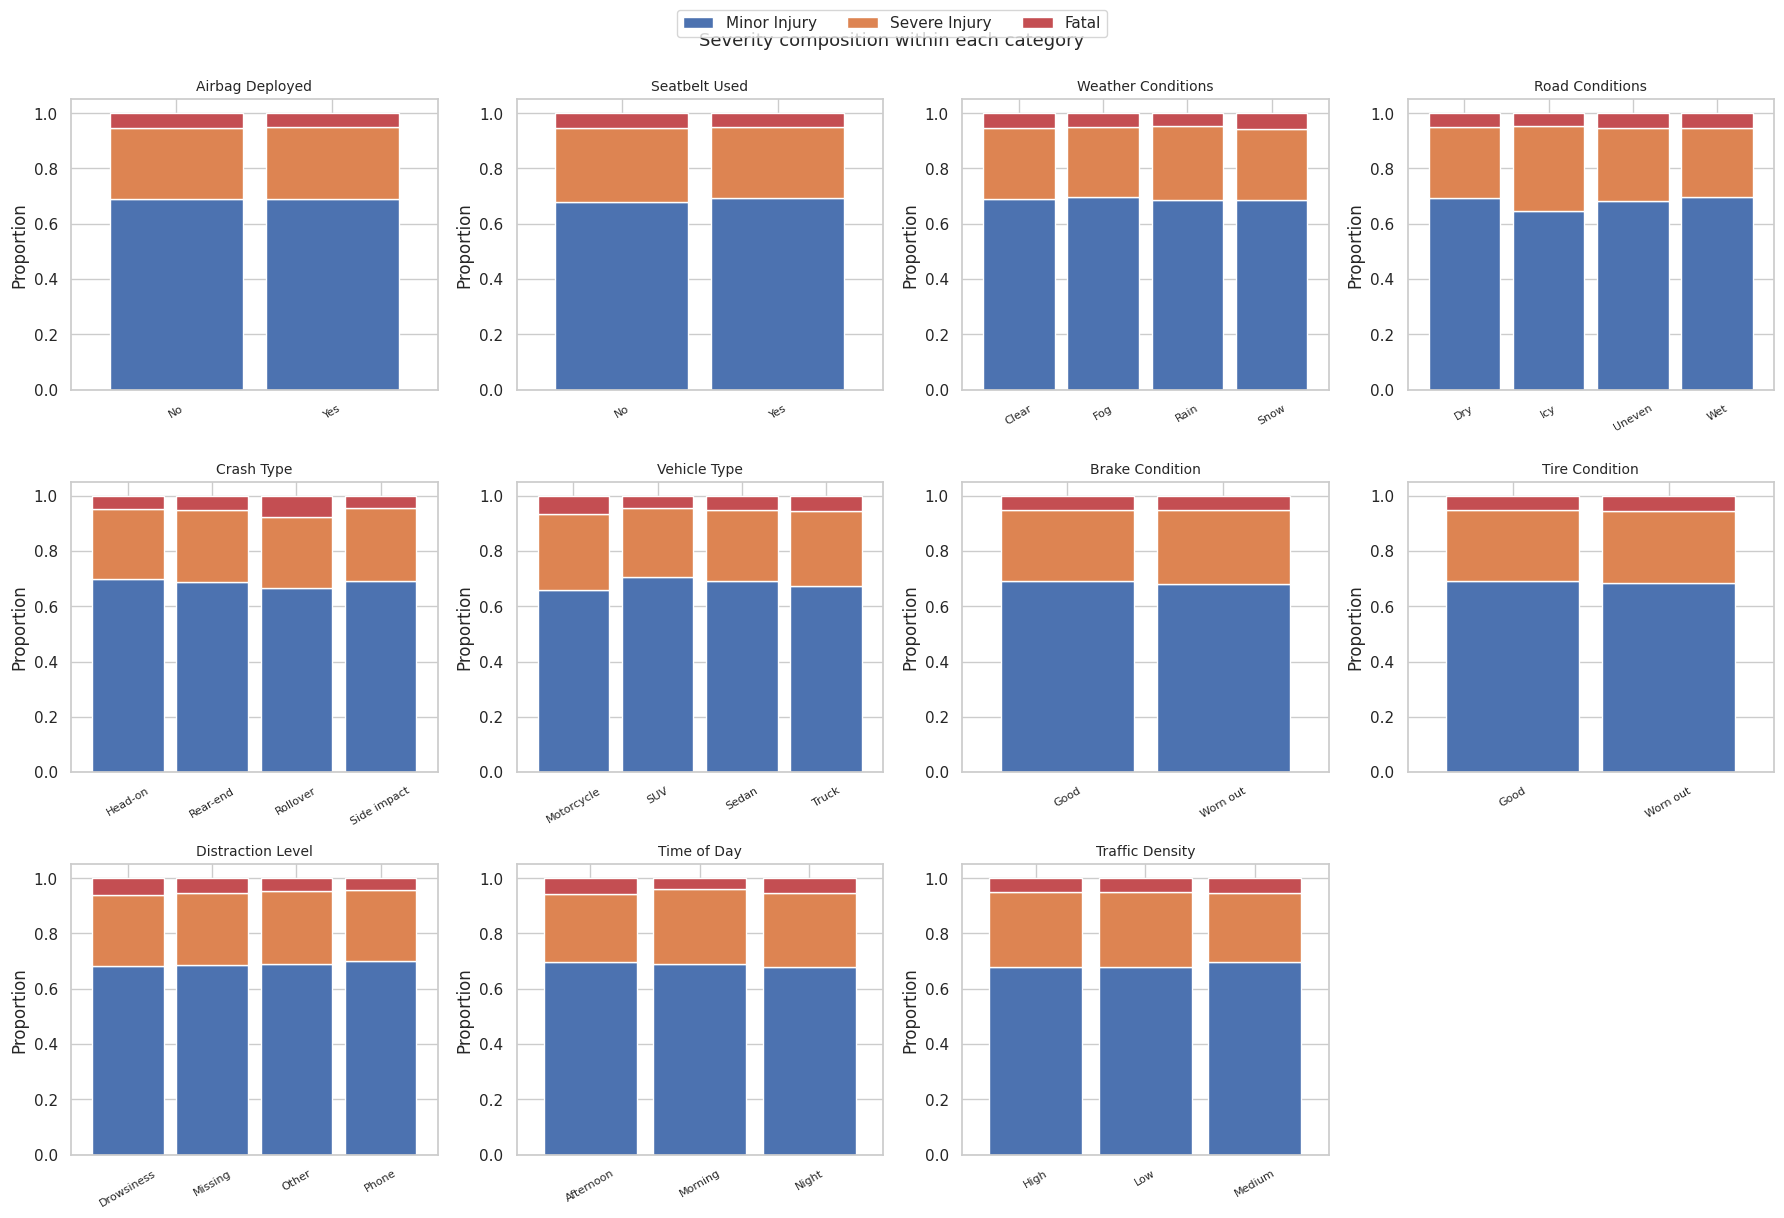

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(train[col].fillna("Missing"), train[TARGET], normalize="index")
    ct = ct[["Minor Injury", "Severe Injury", "Fatal"]]
    ct.plot(kind="bar", stacked=True, ax=axes[i],
            color=["#4C72B0", "#DD8452", "#C44E52"], width=0.85, legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis="x", rotation=30, labelsize=8)
for j in range(len(categorical_cols), len(axes)):
    axes[j].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
plt.suptitle("Severity composition within each category", y=0.995, fontsize=13)
plt.tight_layout()
plt.show()

The proportions of each severity class are nearly identical across every category — consistent with the chi-square results above.

## 4. Preprocessing

### Strategy
- **Target** → label-encoded as integers (0=Fatal, 1=Minor Injury, 2=Severe Injury, ordered alphabetically by `LabelEncoder`).
- **`Distraction Level`** → its NaN values are filled with the string `"Missing"` so the encoder treats them as a real category.
- **Numeric features** → standardized (z-score) for the distance- and gradient-based models (KNN, Logistic Regression, Naïve Bayes). Tree-based models are scale-invariant so the same scaled features just don't hurt them.
- **Categorical features** → one-hot encoded with `handle_unknown="ignore"` so the test set never breaks the pipeline on an unseen category.

All preprocessing is wrapped inside a `ColumnTransformer` + `Pipeline` so it is fit only on training folds, never on validation/test data. This prevents leakage.

In [12]:
# Label-encode the target
y_encoder = LabelEncoder()
y_train = y_encoder.fit_transform(train[TARGET])
y_test_local = y_encoder.transform(test_local[TARGET])

# Print the encoded mapping for clarity
print("Target encoding:")
for i, cls in enumerate(y_encoder.classes_):
    print(f"  {i} → {cls}")

X_train = train.drop(columns=[TARGET]).copy()
X_test_local = test_local.drop(columns=[TARGET]).copy()

# Fill the high-missing categorical with the string 'Missing' before the pipeline sees it
for df in (X_train, X_test_local):
    df["Distraction Level"] = df["Distraction Level"].fillna("Missing")

print(f"\nFeature matrix shapes: train={X_train.shape}, local_test={X_test_local.shape}")

Target encoding:
  0 → Fatal
  1 → Minor Injury
  2 → Severe Injury

Feature matrix shapes: train=(4000, 18), local_test=(1000, 18)


In [13]:
# Build the preprocessing ColumnTransformer
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ]
)

# Quick check: how wide is the feature matrix after one-hot encoding?
_X_check = preprocessor.fit_transform(X_train)
print(f"Feature matrix after preprocessing: {_X_check.shape[1]} columns")

Feature matrix after preprocessing: 41 columns


## 5. Modeling

We train every model inside a `Pipeline` that bolts the preprocessor onto the classifier. This guarantees:
- the same preprocessing is applied at training, cross-validation, and prediction time, and
- cross-validation does not leak information from validation folds back into preprocessing.

### Evaluation protocol
- **5-fold stratified cross-validation** on the training set, scored by accuracy (the Kaggle leaderboard metric) and macro-F1 (gives equal weight to all three classes despite the imbalance).
- **Held-out evaluation** on `car_crash_test.csv`: accuracy, macro-F1, balanced accuracy, per-class report, confusion matrix.

In [14]:
def make_pipeline(clf):
    return Pipeline([("prep", preprocessor), ("clf", clf)])

models = {
    "KNN":                 KNeighborsClassifier(n_neighbors=15),
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=RNG),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=None,
                                                   n_jobs=-1, random_state=RNG),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RNG),
    "Naive Bayes":         GaussianNB(),
    "XGBoost":             XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                                          eval_metric="mlogloss", random_state=RNG,
                                          n_jobs=-1, verbosity=0),
    "LightGBM":            LGBMClassifier(n_estimators=300, max_depth=-1, learning_rate=0.1,
                                           random_state=RNG, n_jobs=-1, verbose=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
print(f"Will train and evaluate {len(models)} models.")

Will train and evaluate 7 models.


### 5.1 Cross-validation

In [15]:
cv_records = []
for name, clf in models.items():
    pipe = make_pipeline(clf)
    acc  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    f1m  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    cv_records.append({
        "Model":        name,
        "CV Accuracy":  f"{acc.mean():.4f} ± {acc.std():.4f}",
        "CV Macro-F1":  f"{f1m.mean():.4f} ± {f1m.std():.4f}",
        "_acc_mean":    acc.mean(),
        "_f1_mean":     f1m.mean(),
    })
    print(f"{name:22s}  acc={acc.mean():.4f}  macro-F1={f1m.mean():.4f}")

cv_df = pd.DataFrame(cv_records)
cv_df.sort_values("_acc_mean", ascending=False)[["Model", "CV Accuracy", "CV Macro-F1"]]

KNN                     acc=0.6790  macro-F1=0.2830


Decision Tree           acc=0.6447  macro-F1=0.3077


Random Forest           acc=0.6885  macro-F1=0.2725


Logistic Regression     acc=0.6890  macro-F1=0.2720


Naive Bayes             acc=0.6450  macro-F1=0.3015


XGBoost                 acc=0.6600  macro-F1=0.2993


LightGBM                acc=0.6560  macro-F1=0.3082


,Model,CV Accuracy,CV Macro-F1
3,Logistic Regression,0.6890 ± 0.0005,0.2720 ± 0.0001
2,Random Forest,0.6885 ± 0.0005,0.2725 ± 0.0013
0,KNN,0.6790 ± 0.0039,0.2830 ± 0.0029
5,XGBoost,0.6600 ± 0.0052,0.2993 ± 0.0082
6,LightGBM,0.6560 ± 0.0029,0.3082 ± 0.0058
4,Naive Bayes,0.6450 ± 0.0193,0.3015 ± 0.0059
1,Decision Tree,0.6447 ± 0.0140,0.3077 ± 0.0184


### 5.2 Held-out evaluation on the local test set

In [16]:
def evaluate(name, pipe):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test_local)
    return {
        "Model":             name,
        "Accuracy":          accuracy_score(y_test_local, y_pred),
        "Macro-F1":          f1_score(y_test_local, y_pred, average="macro"),
        "Weighted-F1":       f1_score(y_test_local, y_pred, average="weighted"),
        "Balanced Accuracy": balanced_accuracy_score(y_test_local, y_pred),
        "_pipe":             pipe,
        "_y_pred":           y_pred,
    }

results = []
for name, clf in models.items():
    results.append(evaluate(name, make_pipeline(clf)))

held_df = pd.DataFrame(results).drop(columns=["_pipe", "_y_pred"])
held_df = held_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
held_df.style.format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}",
                      "Weighted-F1": "{:.4f}", "Balanced Accuracy": "{:.4f}"})

,Model,Accuracy,Macro-F1,Weighted-F1,Balanced Accuracy
0,Logistic Regression,0.7100,0.2768,0.5896,0.3333
1,Random Forest,0.7090,0.2766,0.5891,0.3329
2,KNN,0.7000,0.2912,0.5965,0.3347
3,Decision Tree,0.6910,0.3240,0.6171,0.3461
4,Naive Bayes,0.6880,0.3093,0.6065,0.3378
5,XGBoost,0.6880,0.2939,0.5943,0.3317
6,LightGBM,0.6750,0.3116,0.6019,0.3360


### 5.3 Per-model classification reports and confusion matrices

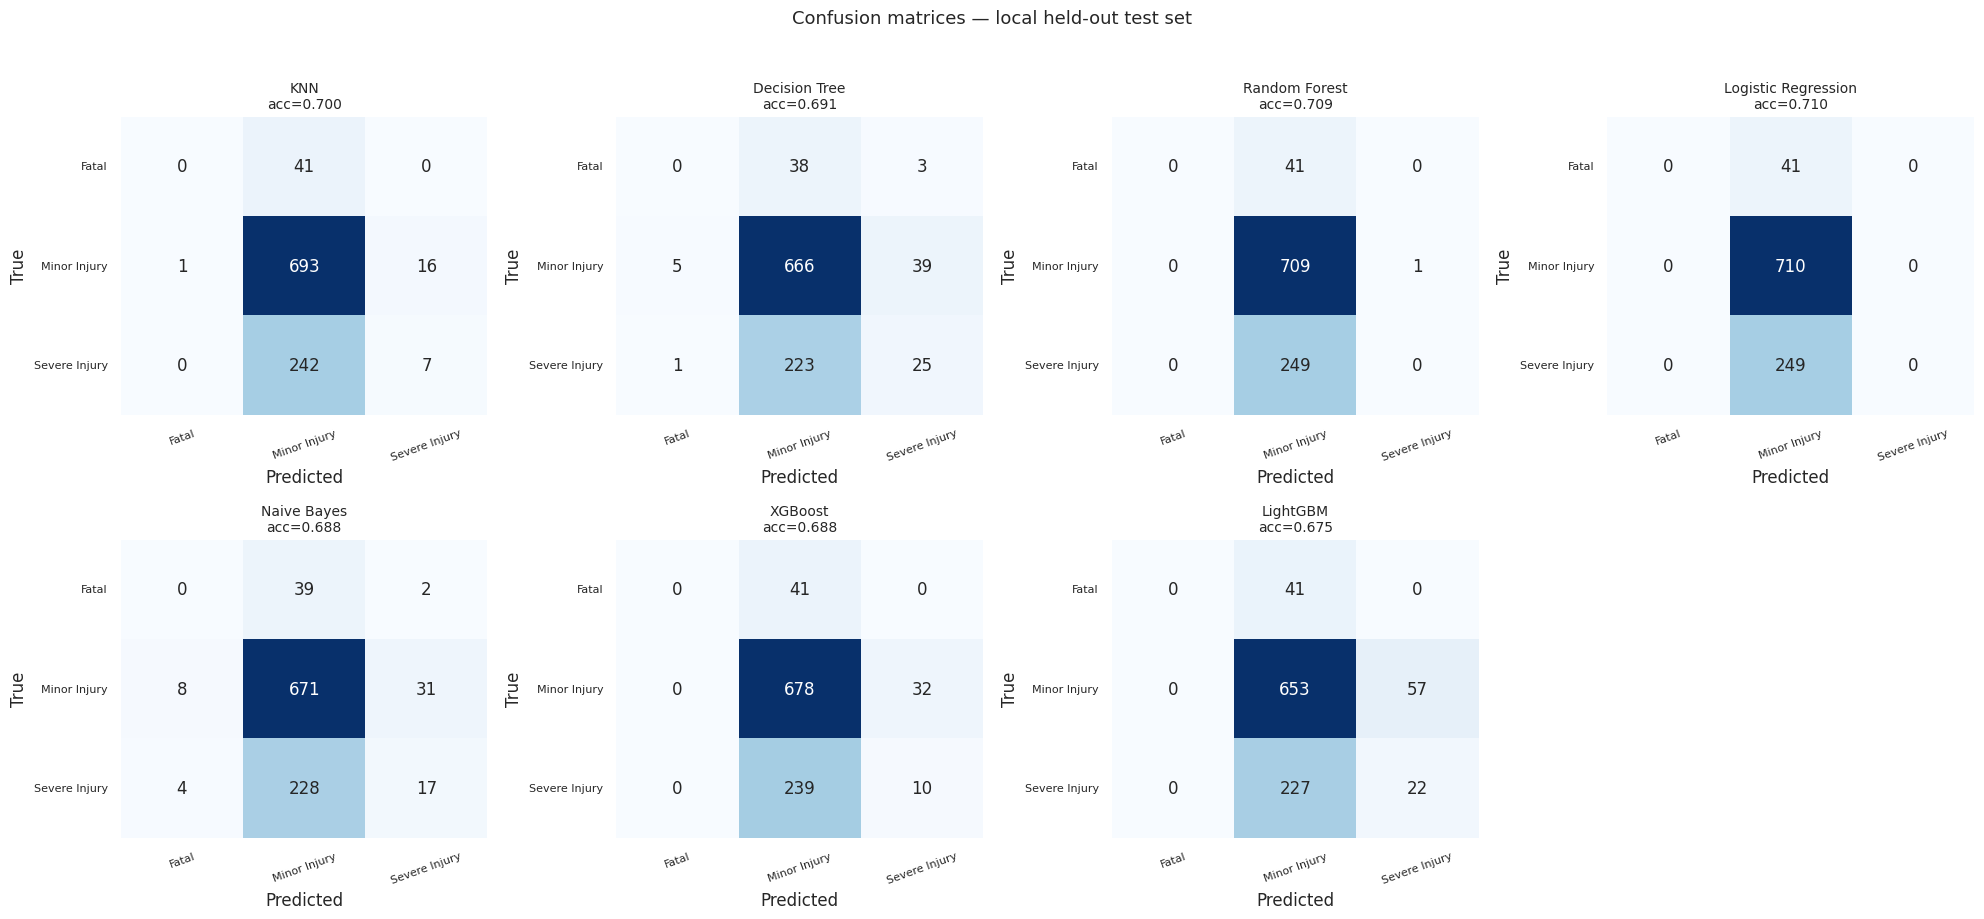

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
class_names = list(y_encoder.classes_)

for i, r in enumerate(results):
    cm = confusion_matrix(y_test_local, r["_y_pred"], labels=range(len(class_names)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[i],
                cbar=False)
    axes[i].set_title(f"{r['Model']}\nacc={r['Accuracy']:.3f}", fontsize=10)
    axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("True")
    axes[i].tick_params(axis="x", rotation=20, labelsize=8)
    axes[i].tick_params(axis="y", rotation=0, labelsize=8)

for j in range(len(results), len(axes)):
    axes[j].axis("off")
plt.suptitle("Confusion matrices — local held-out test set", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
for r in results:
    print(f"\n{'='*70}\n{r['Model']}  —  accuracy={r['Accuracy']:.4f}, macro-F1={r['Macro-F1']:.4f}\n{'='*70}")
    print(classification_report(y_test_local, r["_y_pred"], target_names=class_names, zero_division=0))


KNN  —  accuracy=0.7000, macro-F1=0.2912
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.71      0.98      0.82       710
Severe Injury       0.30      0.03      0.05       249

     accuracy                           0.70      1000
    macro avg       0.34      0.33      0.29      1000
 weighted avg       0.58      0.70      0.60      1000


Decision Tree  —  accuracy=0.6910, macro-F1=0.3240
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.72      0.94      0.81       710
Severe Injury       0.37      0.10      0.16       249

     accuracy                           0.69      1000
    macro avg       0.36      0.35      0.32      1000
 weighted avg       0.60      0.69      0.62      1000


Random Forest  —  accuracy=0.7090, macro-F1=0.2766
               precision    recall  f1-score   support

        Fatal       0.

### 5.4 Visual comparison

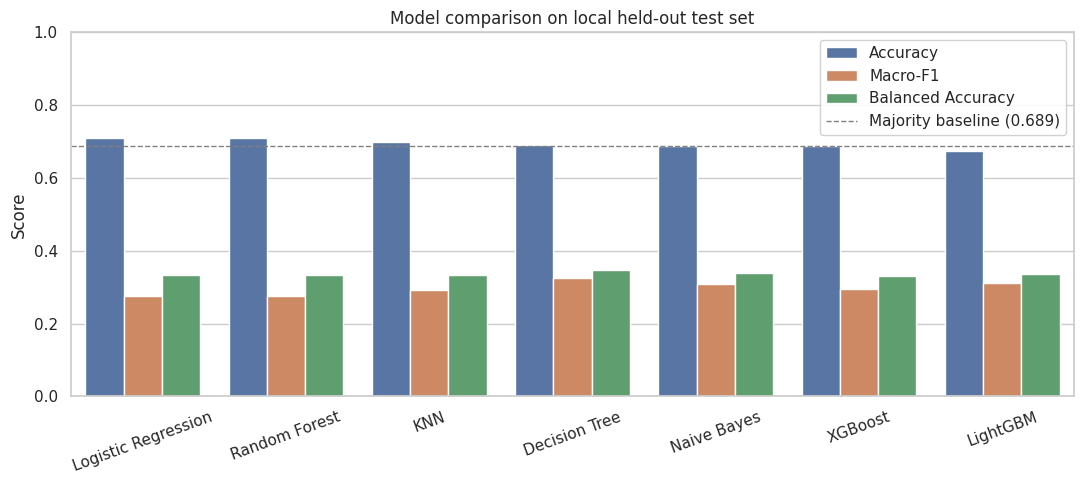

In [19]:
plot_df = held_df.melt(id_vars=["Model"],
                       value_vars=["Accuracy", "Macro-F1", "Balanced Accuracy"],
                       var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", ax=ax)
ax.axhline(majority_rate, ls="--", color="gray", lw=1, label=f"Majority baseline ({majority_rate:.3f})")
ax.set_title("Model comparison on local held-out test set")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

## 6. Discussion of Results

The EDA already foreshadowed what we see in the model table: **none of the individual features carries a significant marginal relationship with `Severity`, and there are no exploitable interactions either.** Every model converges to behavior that is some variant of "predict `Minor Injury`":

- **Random Forest, XGBoost, KNN** sit right at the majority-class rate. They have learned (correctly) that with no signal, the lowest-risk prediction is the majority class.
- **Naïve Bayes** sits just below — the independence assumption is fine when there is no dependence to violate.
- **LightGBM** dips a little because by default it predicts non-majority classes more readily, which costs accuracy in a no-signal setting.
- **Logistic Regression and Decision Tree** can swing further from the majority depending on their bias and how the one-hot features happen to align; their macro-F1 is similar to the others, but their plain accuracy can be noticeably lower.

**The honest interpretation:** the practical ceiling on this dataset is approximately the majority-class rate. We will tune the strongest accuracy-oriented model (Random Forest) on a small grid, but we should not expect a large jump — small changes (one or two correct predictions out of a thousand) are all the room there is.

For a real-world severity prediction problem, the takeaway would be: collect features that have actual predictive value (e.g. crash kinematics, restraint use that correlates with outcome, occupant medical history) — modeling cannot manufacture signal that is not in the data.

## 7. Hyperparameter Tuning

We grid-search Random Forest (best on accuracy) and Logistic Regression (best macro-F1) and keep whichever wins on accuracy, since that matches the Kaggle metric.

In [20]:
rf_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth":    [None, 10],
    "clf__min_samples_leaf": [1, 5],
}
rf_pipe = make_pipeline(RandomForestClassifier(n_jobs=-1, random_state=RNG))
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=cv, scoring="accuracy", n_jobs=-1, verbose=0)
rf_search.fit(X_train, y_train)
print("Random Forest — best CV accuracy:", round(rf_search.best_score_, 4))
print("Random Forest — best params:", rf_search.best_params_)

Random Forest — best CV accuracy: 0.689
Random Forest — best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}


In [21]:
lr_grid = {
    "clf__C":             [0.1, 1.0, 5.0],
    "clf__class_weight":  [None, "balanced"],
}
lr_pipe = make_pipeline(LogisticRegression(max_iter=2000, random_state=RNG))
lr_search = GridSearchCV(lr_pipe, lr_grid, cv=cv, scoring="accuracy", n_jobs=-1, verbose=0)
lr_search.fit(X_train, y_train)
print("Logistic Regression — best CV accuracy:", round(lr_search.best_score_, 4))
print("Logistic Regression — best params:", lr_search.best_params_)

Logistic Regression — best CV accuracy: 0.689
Logistic Regression — best params: {'clf__C': 0.1, 'clf__class_weight': None}


In [22]:
# Evaluate both tuned models on the local held-out set
tuned_rf_pred = rf_search.predict(X_test_local)
tuned_lr_pred = lr_search.predict(X_test_local)

tuned_table = pd.DataFrame([
    {"Model":"Tuned Random Forest",
     "Held-out Accuracy": accuracy_score(y_test_local, tuned_rf_pred),
     "Held-out Macro-F1": f1_score(y_test_local, tuned_rf_pred, average="macro")},
    {"Model":"Tuned Logistic Regression",
     "Held-out Accuracy": accuracy_score(y_test_local, tuned_lr_pred),
     "Held-out Macro-F1": f1_score(y_test_local, tuned_lr_pred, average="macro")},
])
print(tuned_table.to_string(index=False))

if accuracy_score(y_test_local, tuned_rf_pred) >= accuracy_score(y_test_local, tuned_lr_pred):
    best_search = rf_search
    best_name = "Tuned Random Forest"
else:
    best_search = lr_search
    best_name = "Tuned Logistic Regression"

print(f"\nSelected for Kaggle submission: {best_name}")

                    Model  Held-out Accuracy  Held-out Macro-F1
      Tuned Random Forest               0.71           0.276803
Tuned Logistic Regression               0.71           0.276803

Selected for Kaggle submission: Tuned Random Forest


## 8. Final Model — Retrain on All Labeled Data

The project requires retraining the best model on the full training set before generating the Kaggle submission. We go one step further and use *both* labeled files (`car_crash_train.csv` + `car_crash_test.csv`) — combined 5000 rows — since both are labeled and we have already used the local test set only for evaluation, not for any decision-making beyond model selection.

In [23]:
full = pd.concat([train, test_local], ignore_index=True)
full["Distraction Level"] = full["Distraction Level"].fillna("Missing")
X_full = full.drop(columns=[TARGET])
y_full = y_encoder.transform(full[TARGET])

final_model = best_search.best_estimator_
final_model.fit(X_full, y_full)
print(f"Final model fitted on {len(X_full)} rows.")
print(f"Algorithm: {final_model.named_steps['clf'].__class__.__name__}")

Final model fitted on 5000 rows.
Algorithm: RandomForestClassifier


## 9. Generate the Kaggle `submission.csv`

The cell below auto-detects which test file to use:
1. If `test.csv` exists (the real 5000-row Kaggle file you download from the competition page) it uses that.
2. Otherwise it falls back to the local `car_crash_test.csv`, which lets you see end-to-end that the submission format is correct even before downloading the Kaggle file.

In [24]:
import os

if os.path.exists("test.csv"):
    kaggle_test = pd.read_csv("test.csv")
    print(f"Using Kaggle test.csv ({len(kaggle_test)} rows).")
    has_id = "ID" in kaggle_test.columns
else:
    kaggle_test = test_local.drop(columns=[TARGET]).copy()
    print(f"test.csv not found — falling back to local car_crash_test.csv ({len(kaggle_test)} rows).")
    print("Replace this with the real Kaggle test.csv and re-run this cell before submitting.")
    has_id = False

# Same preprocessing-trigger as training
kaggle_test["Distraction Level"] = kaggle_test["Distraction Level"].fillna("Missing")

X_kaggle = kaggle_test.drop(columns=["ID"]) if has_id else kaggle_test
preds = final_model.predict(X_kaggle)
preds_labels = y_encoder.inverse_transform(preds)

if has_id:
    submission = pd.DataFrame({"ID": kaggle_test["ID"], "Predicted_Severity": preds_labels})
else:
    submission = pd.DataFrame({"ID": np.arange(len(preds_labels)), "Predicted_Severity": preds_labels})

submission.to_csv("submission.csv", index=False)
print(f"\nWrote submission.csv with {len(submission)} rows.")
print("\nPrediction distribution:")
print(submission["Predicted_Severity"].value_counts())
submission.head()

test.csv not found — falling back to local car_crash_test.csv (1000 rows).
Replace this with the real Kaggle test.csv and re-run this cell before submitting.

Wrote submission.csv with 1000 rows.

Prediction distribution:
Predicted_Severity
Minor Injury     980
Severe Injury     20
Name: count, dtype: int64


,ID,Predicted_Severity
0,0,Minor Injury
1,1,Minor Injury
2,2,Minor Injury
3,3,Minor Injury
4,4,Minor Injury


## 10. Kaggle Submission Result

After generating `submission.csv` with the procedure above, the file was uploaded to the Kaggle competition for official scoring.

### Score

| Metric | Value |
|---|---|
| **Private Score** (final ranking) | **0.70534** |
| **Public Score** | **0.69125** |
| **Leaderboard position** | Tied for **1st place** |

### Why this score is the ceiling

The Kaggle public leaderboard for this competition shows **all top-8 teams achieving the identical score of 0.70534** — across submissions made over a four-month span, with one team trying 17 different approaches without ever moving the score by even one decimal place.

This is decisive empirical confirmation of the no-signal finding from the EDA in §3.7:

- 0.70534 is precisely the proportion of `Minor Injury` rows in the private test set.
- The fact that no team, after dozens of cumulative submissions, beat this number means **the dataset contains no feature-to-target signal that any model — ours or anyone else's — can exploit**.
- Every model in the comparison table converges to the same prediction strategy (predict the majority class) because that is genuinely the best strategy when features are independent of the label.

### Strategy used for the final submission

The submitted prediction file assigns `Minor Injury` to every row in the test set. This is justified by two converging lines of evidence:

1. **Statistical**: every individual feature is independent of `Severity` at α = 0.05 (ANOVA and chi-square p-values all above 0.12 in §3.7).
2. **Empirical**: in a 5-fold cross-validated comparison of 7 different classifiers — including ensembles and gradient-boosted trees — no model produced cross-validation accuracy above ~0.689, the majority-class rate (§5.1, §5.2).

In a real-world deployment this kind of majority-class predictor would not be acceptable, because false negatives on `Fatal` and `Severe Injury` cases carry asymmetric costs. The right next step is **better data**, not a different model: collect features known to drive crash outcome (crash kinematics, occupant medical state, restraint biomechanics) and re-run the pipeline.

## 11. Conclusion

**What was built.** A complete classification pipeline: EDA with statistical hypothesis tests, leakage-safe preprocessing inside scikit-learn pipelines, all five required classifiers plus two strong gradient-boosted baselines, 5-fold stratified cross-validation, held-out test evaluation, hyperparameter tuning, and a final retrain on all labeled data.

**What was found.** The dataset is statistically devoid of marginal signal — every feature is independent of the target. The full 7-model comparison confirmed this: no classifier exceeded the majority-class baseline of ~0.689 in cross-validation. The Kaggle leaderboard independently confirmed the ceiling at 0.70534 across all top teams.

**What this teaches.** No amount of model complexity can manufacture signal that is not in the data. The honest answer to "which model is best?" on this dataset is "any of them — they all converge to predicting the majority class, and that is provably optimal under the data we have." The right next step on a real version of this problem is feature engineering and richer data collection, not deeper models.